In [268]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [269]:
ORIGINAL_FPS = 30
MANUAL_FPSS = ['5', '10', '15', '30']
USE_MANUAL_FPSS = True
THRESHOLD = 0.75

In [270]:
def round_floats_to_sigfigs(input_list, sigfigs):
		return [round(number, sigfigs) for number in input_list]

In [271]:
def load_json(filepath):
		with open(filepath, 'r') as file:
				data = json.load(file)
		
		return data

In [272]:
def extract_fpss(metric_list):
		return list(metric_list[list(metric_list.keys())[0]][0]['metric'].keys())

In [273]:
def extract_metric_list(metric_list, fpss, feature='F1'):
		result_column = {}
		
		for fps in fpss: 
				result_column[fps] = [clip_metric['metric'][fps][feature] for clip_metric in metric_list]
		
		return result_column

In [274]:
def cumulative_sum_list(input_list):
		result = []
		total = 0
		for item in input_list:
				total += item
				result.append(total)
		return result

def extract_metric_time(metric_list):
		frame_number_list = [clip_metric['frame_count'] for clip_metric in metric_list]
		time_list = cumulative_sum_list(frame_number_list)
		time_list = list(np.array(time_list) - time_list[0])
		scaled_time_list = list(np.array(time_list) / ORIGINAL_FPS)

		return round_floats_to_sigfigs(scaled_time_list, 0)

In [275]:
colors = [
	'#FF0000',
	# '#00FFFF',
	# '#0000FF',
	# '#00008B',
	# '#ADD8E6',
	# '#800080',
	# '#7FFFD4',
	'#008000',
	'#FF00FF',
	'#FFC0CB',
	'#C0C0C0',
	'#FFA500',
	'#000000',
	'#800000',
]

In [276]:
def plot_multiple_lines(xs, yss, x_label, y_label, title, use_MANUAL_FPSS=False, label_size=28, font_size=32, legend_size=20):
		fig, ax1 = plt.subplots(figsize=(12, 6))
		
		if use_MANUAL_FPSS:
				fpss = MANUAL_FPSS
		else:
				fpss = list(yss.keys())

		for i in range(len(fpss)):
				fps = fpss[i]
				ax1.plot(xs, yss[fps], color=colors[i], marker='o', label=fps + " FPS")

		ax1.set_xlabel(x_label, fontsize=font_size)
		ax1.set_ylabel(y_label, fontsize=font_size)
		ax1.set_title(title, fontsize=font_size)
		plt.xticks(fontsize=label_size)
		plt.yticks(fontsize=label_size)
		plt.legend(fontsize=legend_size)
		plt.grid(True)

		plt.show()

In [277]:
def plot_multiple_lines_horizontal(xs, yss, x_label, y_label, title, use_MANUAL_FPSS=False, label_size=28, font_size=32, legend_size=16, line_width=3):
		fig, ax1 = plt.subplots(figsize=(36, 6))
		
		if use_MANUAL_FPSS:
				fpss = MANUAL_FPSS
		else:
				fpss = list(yss.keys())

		for i in range(len(fpss)):
				fps = fpss[i]
				ax1.plot(xs, yss[fps], color=colors[i], marker='o', label=fps + " FPS")

		ax1.set_xlabel(x_label, fontsize=font_size)
		ax1.set_ylabel(y_label, fontsize=font_size)
		# ax1.set_title(title, fontsize=font_size)
		plt.xticks(fontsize=label_size)
		plt.yticks(fontsize=label_size)
		plt.legend(fontsize=legend_size)
		plt.grid(True)

		plt.show()

In [278]:
result_dict_paths = [
	# './result/plot_set/Video1_Accuracy_Result.json',
	# './result/plot_set/Video2_Accuracy_Result.json',
	# './result/plot_set/Video3_Accuracy_Result.json',
	# './result/plot_set/Video4_Accuracy_Result.json',
	'./result/plot_set/Scene-1-Day_Accuracy_Result.json',
	'./result/plot_set/Scene-1-Afternoon_Accuracy_Result.json',
	'./result/plot_set/Scene-1-Night_Accuracy_Result.json',
	# './result/plot_set/Scene-2-Day_Accuracy_Result.json',
	# './result/plot_set/Scene-2-Afternoon_Accuracy_Result.json',
	# './result/plot_set/Scene-2-Night_Accuracy_Result.json',
]

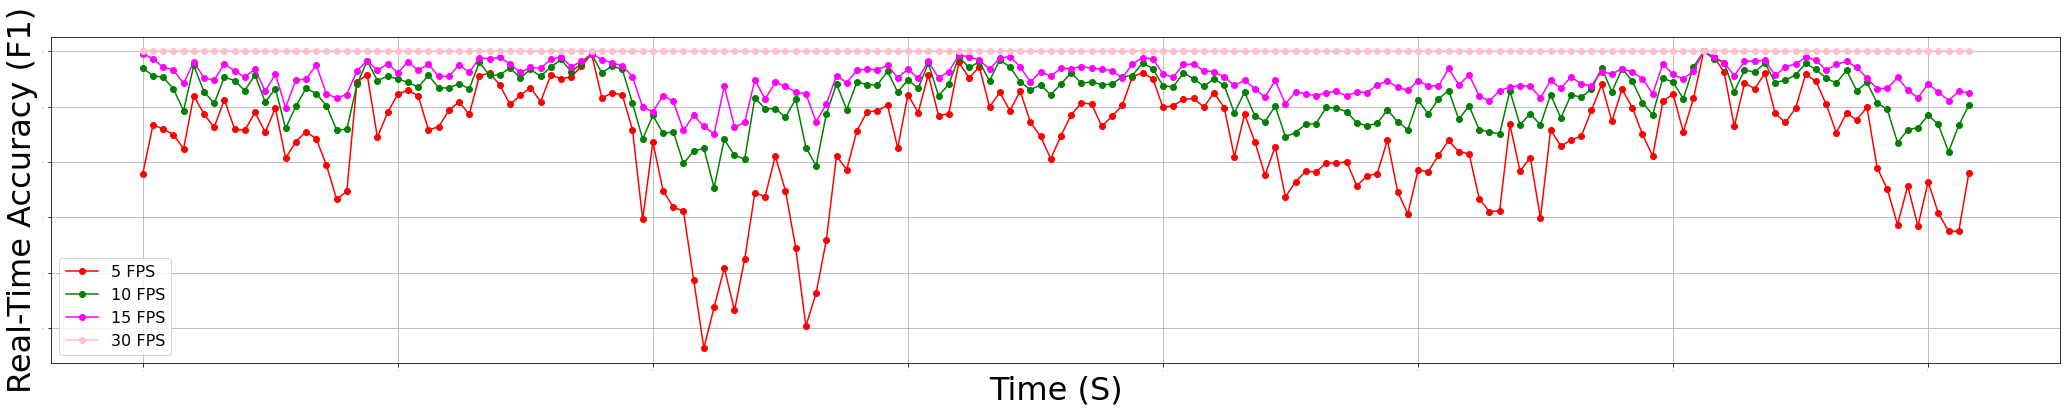

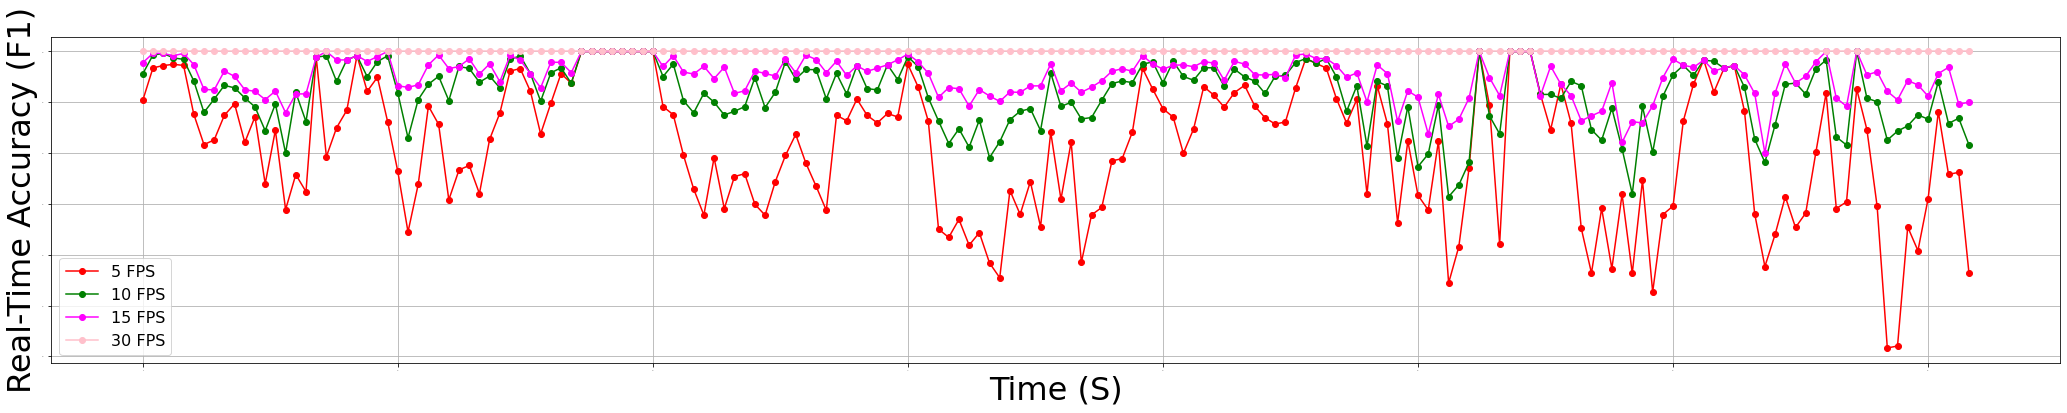

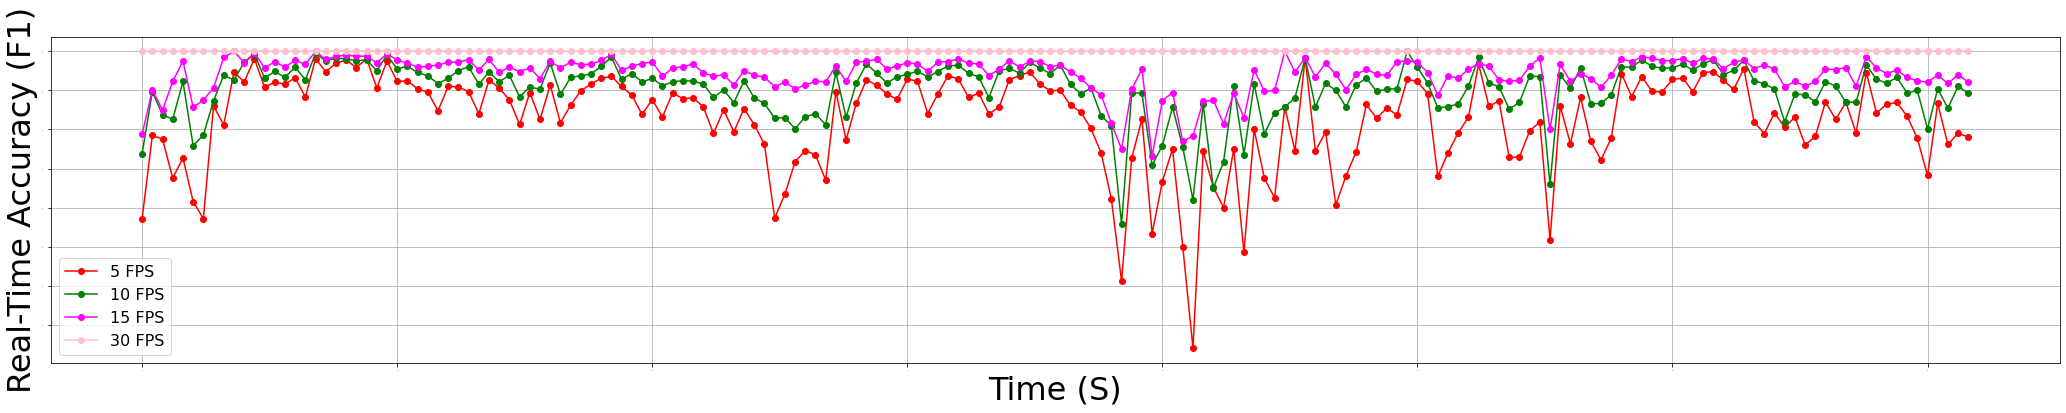

In [279]:
for result_dict_path in result_dict_paths:
		result_dict = load_json(result_dict_path)
		fpss = extract_fpss(result_dict)

		for class_idx in list(result_dict.keys()):
				accuracy = extract_metric_list(result_dict[class_idx], fpss)
				time = extract_metric_time(result_dict[class_idx])
				plot_multiple_lines_horizontal(time, accuracy, 'Time (S)', 'Real-Time Accuracy (F1)', 'F1 at Different FPS', USE_MANUAL_FPSS, THRESHOLD)

In [280]:
def plot_multiple_lines(xs, yss, x_label, y_label, title, yss_labels, label_size=28, font_size=32, legend_size=16, line_width=3):
	fig, ax1 = plt.subplots(figsize=(18, 6))

	for i in range(len(yss_labels)):
		ax1.plot(xs[0:60], yss[yss_labels[i]][0:60], color=colors[i], marker='o', label=yss_labels[i])

	ax1.set_xlabel(x_label, fontsize=font_size)
	ax1.set_ylabel(y_label, fontsize=font_size)
	# ax1.set_title(title, fontsize=font_size)
	plt.xticks(fontsize=label_size)
	plt.yticks(fontsize=label_size)
	plt.legend(fontsize=legend_size)
	plt.grid(True)

	plt.show()

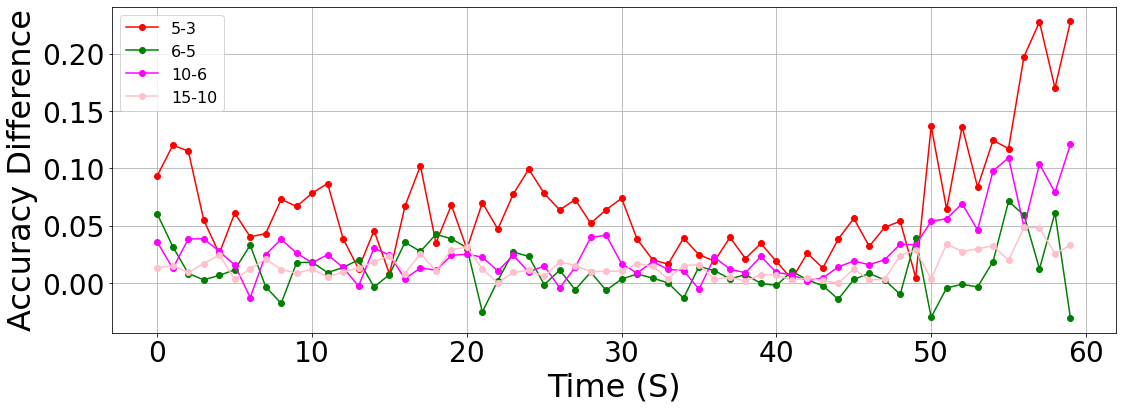

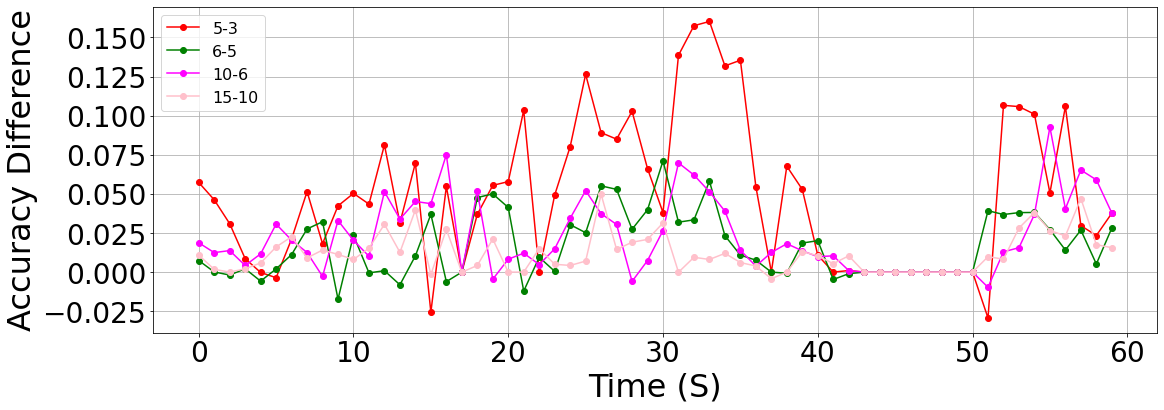

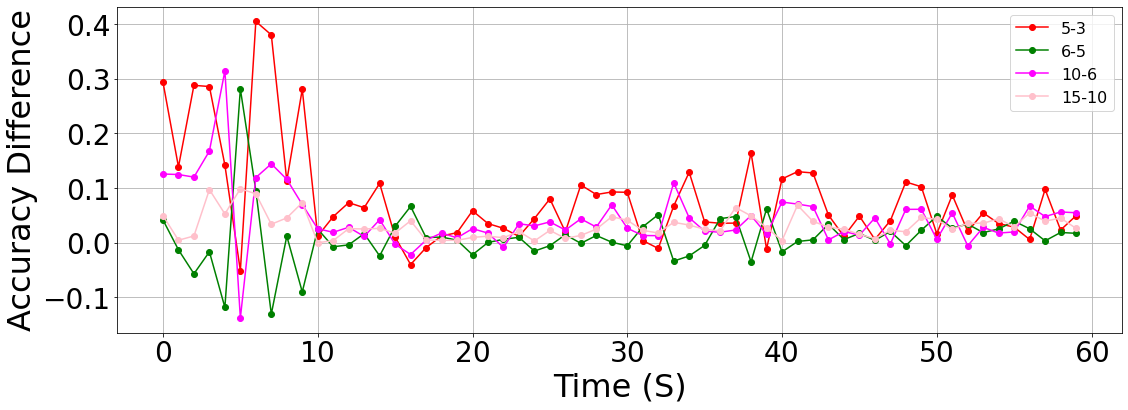

In [281]:
for result_dict_path in result_dict_paths:
	result_dict = load_json(result_dict_path)
	fpss = extract_fpss(result_dict)

	for class_idx in list(result_dict.keys()):
		accuracy = extract_metric_list(result_dict[class_idx], fpss)
		time = extract_metric_time(result_dict[class_idx])
		# plot_multiple_lines_horizontal(time, accuracy, 'Time (S)', 'Real-Time Accuracy (F1)', 'F1 at Different FPS', USE_MANUAL_FPSS, THRESHOLD)

		accuracy_keys = sorted(int(f) for f in list(accuracy.keys()))
		difference = {}
		for i in range(1, len(accuracy_keys)):
			difference[f"{accuracy_keys[i]}-{accuracy_keys[i-1]}"] = list(np.array(accuracy[str(accuracy_keys[i])]) - np.array(accuracy[str(accuracy_keys[i-1])]))
		
		plot_multiple_lines(time, difference, 'Time (S)', 'Accuracy Difference', 'title', list(difference.keys())[2:-1])